In [1]:
# TASK 1.1 = IMPORT DATASETS #
import pandas as pd

df_ev = pd.read_excel(r"C:\Users\AKSHITA\Downloads\States_Electric_Vehicle_Registrations_2018.xlsx")
df_energy = pd.read_excel(r"C:\Users\AKSHITA\Downloads\States_Annual_Energy_Generation_Sources_1990_2019.xlsx")
df_vehicle = pd.read_excel(r"C:\Users\AKSHITA\Downloads\States_All_Vehicle_Registrations_2018.xlsx")
df_state = pd.read_excel(r"C:\Users\AKSHITA\Downloads\state_codes.xlsx")



In [2]:
#  TASK 1.2 = CHECKING MISIING VALUES THOROUGHLY ---------------

In [3]:
# EV DATASE--------------
df_ev = pd.read_excel(r"C:\Users\AKSHITA\Downloads\States_Electric_Vehicle_Registrations_2018.xlsx", sheet_name='Condensed', skiprows=1)
df_ev.columns = ['blank', 'State', 'Registration_Count']
df_ev = df_ev.drop(columns='blank')
df_ev = df_ev[df_ev['State'].notna()]
df_ev = df_ev[df_ev['State'] != 'State']

df_ev['Registration_Count'] = pd.to_numeric(df_ev['Registration_Count'], errors='coerce')

df_ev.head()
df_ev.isnull().sum()

State                 0
Registration_Count    0
dtype: int64

In [4]:
# ENERGY DATASE-----------
df_energy.columns = ['Year', 'State_Code', 'State', 'Energy_Source', 'Generation_MWh']

# remove header-like row
df_energy['Year'] = pd.to_numeric(df_energy['Year'], errors='coerce')
df_energy = df_energy[df_energy['Year'].notna()]

df_energy['Generation_MWh'] = pd.to_numeric(df_energy['Generation_MWh'], errors='coerce')

df_energy.head()
df_energy.isnull().sum()

Year              0
State_Code        0
State             0
Energy_Source     0
Generation_MWh    0
dtype: int64

In [5]:
# VEHICLE DATASET
# keep only actual state rows


In [6]:

df_vehicle.isnull().sum()

                8
Unnamed: 1      6
Unnamed: 2     10
Unnamed: 3     11
Unnamed: 4      9
Unnamed: 5     10
Unnamed: 6     11
Unnamed: 7      9
Unnamed: 8     10
Unnamed: 9     11
Unnamed: 10     9
Unnamed: 11    10
Unnamed: 12    11
Unnamed: 13     9
Unnamed: 14    10
Unnamed: 15    10
dtype: int64

In [7]:
df_vehicle = pd.read_excel(
    r"C:\Users\AKSHITA\Downloads\States_All_Vehicle_Registrations_2018.xlsx",
    sheet_name='MV1',
    skiprows=7)

In [8]:
df_vehicle = df_vehicle.iloc[4:55].copy()

In [9]:
df_vehicle = df_vehicle.dropna(axis=1, how='all')

In [10]:
df_vehicle.columns = [
    'State',
    'Automobiles_Private_Commercial', 'Automobiles_Publicly_Owned', 'Automobiles_Total',
    'Buses_Private_Commercial', 'Buses_Publicly_Owned', 'Buses_Total',
    'Trucks_Private_Commercial', 'Trucks_Publicly_Owned', 'Trucks_Total',
    'Motorcycles_Private_Commercial', 'Motorcycles_Publicly_Owned', 'Motorcycles_Total',
    'AllVehicles_Private_Commercial', 'AllVehicles_Publicly_Owned', 'AllVehicles_Total']

In [11]:
df_vehicle.replace(['—', '-'], 0, inplace=True)

C:\Users\AKSHITA\AppData\Local\Temp\ipykernel_13904\3538807381.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_vehicle.replace(['—', '-'], 0, inplace=True)


In [12]:
df_vehicle['State'] = df_vehicle['State'].astype(str).str.replace(r'\s*\(2\)$', '', regex=True).str.strip()

In [13]:
for col in df_vehicle.columns[1:]:
    df_vehicle[col] = pd.to_numeric(df_vehicle[col], errors='coerce')

In [14]:
#STATE CODE DATASET------------
df_state.head()
df_state.isnull().sum()

state_code    0
state_name    0
dtype: int64

In [15]:
df_vehicle.head()
df_vehicle.isnull().sum()

State                             0
Automobiles_Private_Commercial    0
Automobiles_Publicly_Owned        0
Automobiles_Total                 0
Buses_Private_Commercial          0
Buses_Publicly_Owned              0
Buses_Total                       0
Trucks_Private_Commercial         0
Trucks_Publicly_Owned             0
Trucks_Total                      0
Motorcycles_Private_Commercial    0
Motorcycles_Publicly_Owned        0
Motorcycles_Total                 0
AllVehicles_Private_Commercial    0
AllVehicles_Publicly_Owned        0
AllVehicles_Total                 0
dtype: int64

In [2]:
"""“The dataset was initially in a formatted report layout with multiple header
and non-data rows. These rows were removed, and the dataset was restructured 
into a tabular format suitable for analysis.


After thorough data cleaning, it was observed that the datasets did not
contain any true missing values. Apparent missing values were due to formatting
issues and symbolic representations such as ‘—’, which were replaced with 0 to
maintain data integrity."""


'“The dataset was initially in a formatted report layout with multiple header\nand non-data rows. These rows were removed, and the dataset was restructured \ninto a tabular format suitable for analysis.\n\n\nAfter thorough data cleaning, it was observed that the datasets did not\ncontain any true missing values. Apparent missing values were due to formatting\nissues and symbolic representations such as ‘—’, which were replaced with 0 to\nmaintain data integrity.'

In [ ]:
#🚀 ✅ TASK 2.1: Exploratory Data Analysis (EDA)

In [ ]:
#🚀 ✅ TASK 2.1: Exploratory Data Analysis (EDA
df_vehicle.head()
df_vehicle.describe()
"""“The dataset contains vehicle registration counts across different states
categorized by vehicle types such as automobiles, buses, trucks, and 
motorcycles.”""

In [ ]:
#🔹 Task 2.1.2: Top States by Total Vehicles
df_vehicle.sort_values(by='AllVehicles_Total', ascending=False).head(10)

""States with the highest number of registered vehicles indicate higher 
transportation demand and urbanization.

In [ ]:
 # Task 2.1.3: Total Vehicles Distribution
 df_vehicle['AllVehicles_Total'].describe()



In [ ]:
""Insight:

“The distribution shows variation in vehicle ownership across states
, with some states having significantly higher registrations.

In [ ]:
#TASK 2.2: Data Visualization
#Bar Chart (Top 10 States)

In [ ]:
import matplotlib.pyplot as plt

top_states = df_vehicle.sort_values(by='AllVehicles_Total', ascending=False).head(10)

plt.figure()
plt.bar(top_states['State'], top_states['AllVehicles_Total'])
plt.xticks(rotation=45)
plt.title("Top 10 States by Total Vehicles")
plt.xlabel("State")
plt.ylabel("Total Vehicles")
plt.show()

#“The bar chart shows the top states with the highest vehicle registrations, 
#highlighting regions with dense transportation activity.

In [ ]:
#2. Vehicle Type Comparison
vehicle_sum = df_vehicle[['Automobiles_Total','Buses_Total','Trucks_Total','Motorcycles_Total']].sum()

vehicle_sum.plot(kind='bar')
plt.title("Vehicle Type Distribution")
plt.show()

"""Motorcycles and automobiles dominate the total vehicle count compared to
buses and trucks""

In [ ]:
#Histogram (Distribution)
plt.hist(df_vehicle['AllVehicles_Total'])
plt.title("Distribution of Total Vehicles")
plt.show()

"""“The distribution is skewed, indicating that only a few states have
extremely high vehicle counts."""

In [ ]:
#Box Plot (Outliers)
plt.boxplot(df_vehicle['AllVehicles_Total'])
plt.title("Outliers in Vehicle Data")
plt.show()

"""The box plot highlights outliers, indicating states with exceptionally 
high vehicle registrations."""

In [ ]:
#Scatter Plot (Relationship)
plt.scatter(df_vehicle['Automobiles_Total'], df_vehicle['AllVehicles_Total'])
plt.xlabel("Automobiles")
plt.ylabel("Total Vehicles")
plt.title("Automobiles vs Total Vehicles")
plt.show()
"""“A strong positive relationship exists between automobiles and 
total vehicle registrations."""

In [ ]:
# Task 3.1 Correlation Analysis

In [97]:
# . Create EV Percentage
df_merged.rename(columns={'Registration_Count': 'EV_Registrations'}, inplace=True)

df_merged['EV_Percentage'] = (df_merged['EV_Registrations'] / df_merged['AllVehicles_Total']) * 100

In [98]:
# Correlation Matrix---------------
corr = df_merged[['EV_Registrations', 'AllVehicles_Total', 'Generation_MWh', 'EV_Percentage']].corr()
corr

,EV_Registrations,AllVehicles_Total,Generation_MWh,EV_Percentage
EV_Registrations,1.000000,0.746879,0.316362,0.758449
AllVehicles_Total,0.746879,1.000000,0.821922,0.480408
Generation_MWh,0.316362,0.821922,1.000000,0.103840
EV_Percentage,0.758449,0.480408,0.103840,1.000000


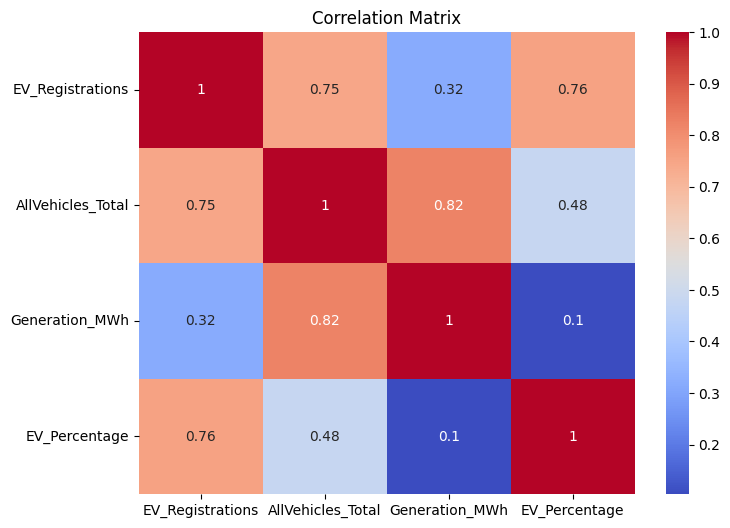

In [99]:
# Heatmap -----------------
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

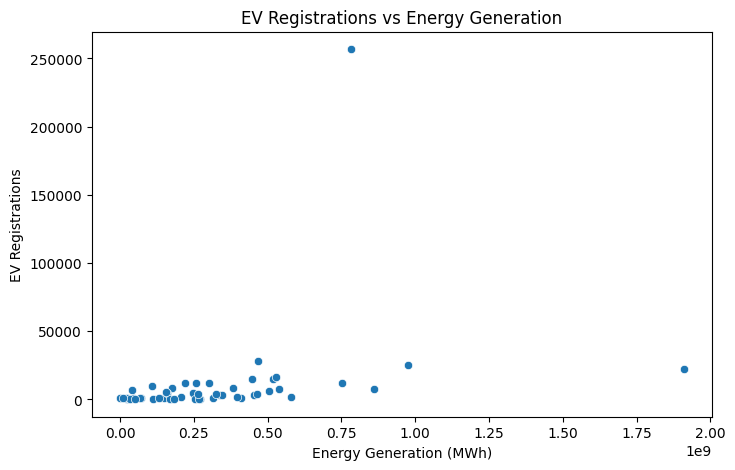

In [100]:
#  Scatter Plot: EV Registrations vs Energy Generation--------------
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_merged, x='Generation_MWh', y='EV_Registrations')
plt.title('EV Registrations vs Energy Generation')
plt.xlabel('Energy Generation (MWh)')
plt.ylabel('EV Registrations')
plt.show()

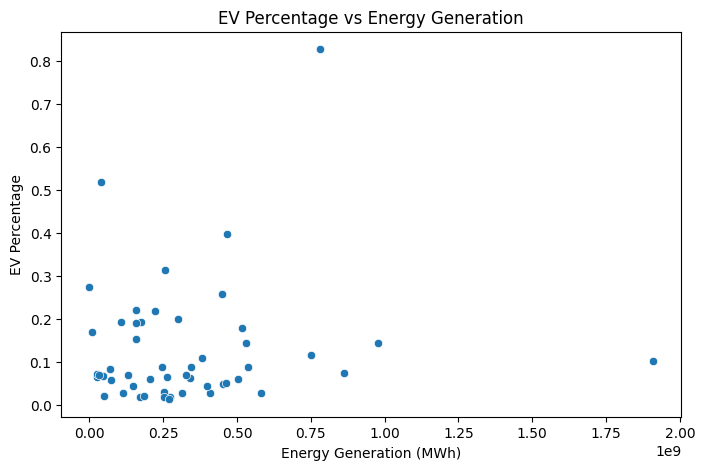

In [101]:
# Scatter Plot: EV Percentage vs Energy Generation-----------
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_merged, x='Generation_MWh', y='EV_Percentage')
plt.title('EV Percentage vs Energy Generation')
plt.xlabel('Energy Generation (MWh)')
plt.ylabel('EV Percentage')
plt.show()

In [ ]:
#Task 3.1
"""State-level EV registrations, total vehicle registrations, and 2018 energy 
generation data were merged using state codes. Correlation analysis was
performed to understand the relationship between EV adoption and energy 
generation."""

In [102]:
# Task 3.2 Statistical Strength-----------
from scipy.stats import pearsonr

r1, p1 = pearsonr(df_merged['Generation_MWh'], df_merged['EV_Registrations'])
r2, p2 = pearsonr(df_merged['Generation_MWh'], df_merged['EV_Percentage'])

print("EV Registrations vs Energy Generation")
print("Pearson r:", r1)
print("p-value:", p1)

print("\nEV Percentage vs Energy Generation")
print("Pearson r:", r2)
print("p-value:", p2)

EV Registrations vs Energy Generation
Pearson r: 0.316362308159165
p-value: 0.02371567513601963

EV Percentage vs Energy Generation
Pearson r: 0.10383993952129472
p-value: 0.4683630681566345


In [ ]:
"""Pearson correlation was used to measure the strength and significance
of the relationship between energy generation and EV adoption indicators.
The correlation coefficient indicates the direction and strength of the
relationship, while the p-value shows statistical significance"""

In [ ]:
# TASK 4 = TIME SERIES ANALYSIS:


In [ ]:
# TASK 4.1
energy_yearly = df_energy.groupby('Year', as_index=False)['Generation_MWh'].sum()
energy_yearly.head()

"""The energy dataset contains yearly renewable energy generation values, 
making it suitable for time series analysis."""

In [ ]:
# 4.1.2 Plot total energy production over time
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(energy_yearly['Year'], energy_yearly['Generation_MWh'], marker='o')
plt.title('Total Energy Generation Over Time')
plt.xlabel('Year')
plt.ylabel('Generation (MWh)')
plt.grid(True)
plt.show()

"""This line plot shows how total energy generation changed over time and
helps identify long-term growth or decline."""

In [ ]:
#4.1.3 Analyze by energy source over time
energy_source_yearly = df_energy.groupby(['Year', 'Energy_Source'], as_index=False)['Generation_MWh'].sum()
energy_source_yearly.head()

In [ ]:
#4.1.4 Plot energy source trends
plt.figure(figsize=(12,6))

for source in energy_source_yearly['Energy_Source'].unique():
    subset = energy_source_yearly[energy_source_yearly['Energy_Source'] == source]
    plt.plot(subset['Year'], subset['Generation_MWh'], label=source)

plt.title('Energy Generation by Source Over Time')
plt.xlabel('Year')
plt.ylabel('Generation (MWh)')
plt.legend()
plt.grid(True)
plt.show()


"""This visualization compares the contribution of different energy sources
across years and highlights which sources are growing or declining."""


In [ ]:
# Task 4.2: Seasonal Trends or Long-Term Shifts

In [ ]:
# 4.2.1 Long-term trend using rolling average
energy_yearly['Rolling_Mean_3'] = energy_yearly['Generation_MWh'].rolling(window=3).mean()

plt.figure(figsize=(10,5))
plt.plot(energy_yearly['Year'], energy_yearly['Generation_MWh'], label='Original')
plt.plot(energy_yearly['Year'], energy_yearly['Rolling_Mean_3'], label='3-Year Rolling Mean')
plt.title('Long-Term Trend in Energy Generation')
plt.xlabel('Year')
plt.ylabel('Generation (MWh)')
plt.legend()
plt.grid(True)
plt.show()

# “The rolling mean smooths yearly fluctuations and makes the long-term trend
# easier to observe.”

In [ ]:
# 4.2.2 Year-over-year change
energy_yearly['YoY_Change'] = energy_yearly['Generation_MWh'].pct_change() * 100
energy_yearly.head()

In [ ]:
# 4.2.3 Plot year-over-year change
plt.figure(figsize=(10,5))
plt.bar(energy_yearly['Year'], energy_yearly['YoY_Change'])
plt.title('Year-over-Year Percentage Change in Energy Generation')
plt.xlabel('Year')
plt.ylabel('YoY Change (%)')
plt.grid(True)
plt.show()

"""This chart shows how strongly energy generation increased or decreased 
from one year to the next"""

In [ ]:
"""Time series analysis revealed long-term changes in annual energy generation
across the United States. Source-wise trends showed variation in the growth 
patterns of different energy sources. Since the EV registration dataset was 
limited to a single year, time-based EV trend analysis could not be fully
performed with the available data."""

In [ ]:
# TASK 5 = State-wise EV Distribution

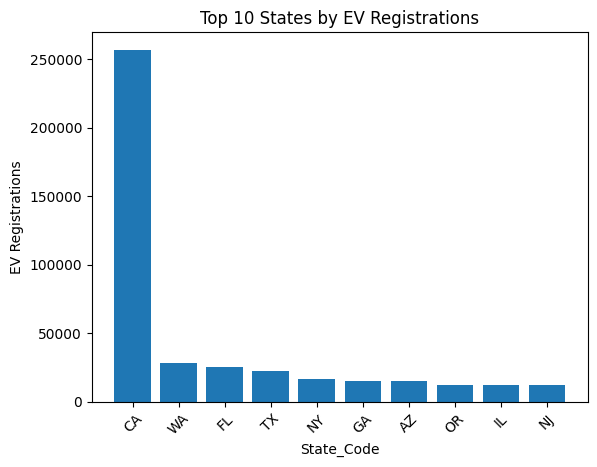

' The chart highlights the top states with the highest EV registrations,\nindicating regions with stronger adoption of electric vehicle'

In [110]:
# Top 10 states by EV registrations------------
top_ev = df_merged.sort_values(by='EV_Registrations', ascending=False).head(10)

import matplotlib.pyplot as plt

plt.figure()
plt.bar(top_ev['State_Code'], top_ev['EV_Registrations'])
plt.xticks(rotation=45)
plt.title("Top 10 States by EV Registrations")
plt.xlabel("State_Code")
plt.ylabel("EV Registrations")
plt.show()
""" The chart highlights the top states with the highest EV registrations,
indicating regions with stronger adoption of electric vehicle"""

In [106]:
df_merged.columns

Index(['State_x', 'EV_Registrations', 'State_Code', 'State_y',
       'AllVehicles_Total', 'Generation_MWh', 'EV_Percentage'],
      dtype='object')

In [ ]:
""" The chart highlights the top states with the highest EV registrations,
indicating regions with stronger adoption of electric vehicle"""

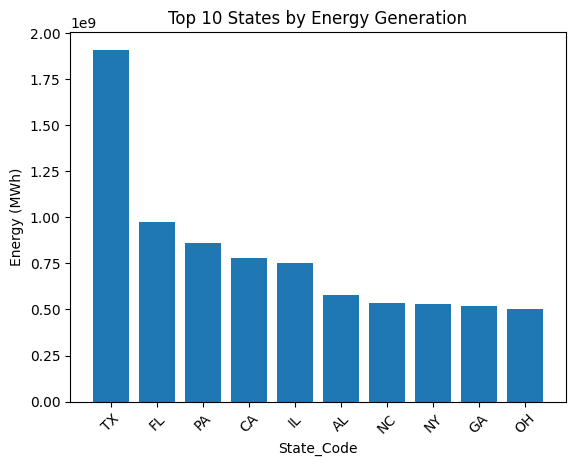

'The chart shows states with the highest energy production, reflecting regions with strong energy infrastructure'

In [109]:
# 5.2 – State-wise Energy Distribution-----------
top_energy = df_merged.sort_values(by='Generation_MWh', ascending=False).head(10)

plt.figure()
plt.bar(top_energy['State_Code'], top_energy['Generation_MWh'])
plt.xticks(rotation=45)
plt.title("Top 10 States by Energy Generation")
plt.xlabel("State_Code")
plt.ylabel("Energy (MWh)")
plt.show()
"""The chart shows states with the highest energy production, reflecting regions with strong energy infrastructure"""

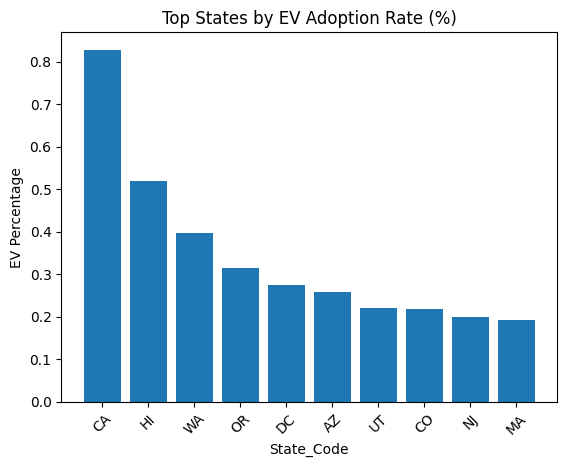

'This chart shows the states with the highest EV adoption rate relative to total vehicles, providing a more accurate comparison than absolute EV counts'

In [113]:
# Task 5.3 – EV Adoption Rate---------
top_ev_percent = df_merged.sort_values(by='EV_Percentage', ascending=False).head(10)

plt.figure()
plt.bar(top_ev_percent['State_Code'], top_ev_percent['EV_Percentage'])
plt.xticks(rotation=45)
plt.title("Top States by EV Adoption Rate (%)")
plt.xlabel("State_Code")
plt.ylabel("EV Percentage")
plt.show()
"""This chart shows the states with the highest EV adoption rate relative to total vehicles, providing a more accurate comparison than absolute EV counts"""

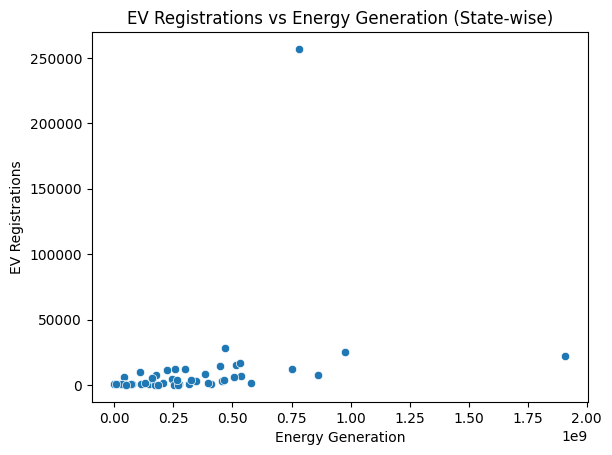

'The scatter plot shows the relationship between energy production and EV registrations across states, supporting the correlation analysis'

In [114]:
# 5.4 – EV vs Energy Comparison----------
plt.figure()
sns.scatterplot(data=df_merged, x='Generation_MWh', y='EV_Registrations')
plt.title("EV Registrations vs Energy Generation (State-wise)")
plt.xlabel("Energy Generation")
plt.ylabel("EV Registrations")
plt.show()
"""The scatter plot shows the relationship between energy production and EV registrations across states, supporting the correlation analysis"""

In [ ]:
"""The geospatial analysis reveals that EV adoption is concentrated in certain
states with strong energy infrastructure. While high energy generation is 
associated with higher EV registrations, the adoption rate varies across 
states, indicating the influence of additional factors such as policies and
infrastructure"""

In [115]:
# TASK 6
 # BUILD PREDICTIVE MODELS TO FORECAST--------------


In [116]:
X = df_merged[['AllVehicles_Total', 'Generation_MWh']]
y = df_merged['EV_Registrations']

In [117]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [118]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [119]:
y_pred = model.predict(X_test)

In [120]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 12155.503806511191
R2 Score: -3.7910816487419456


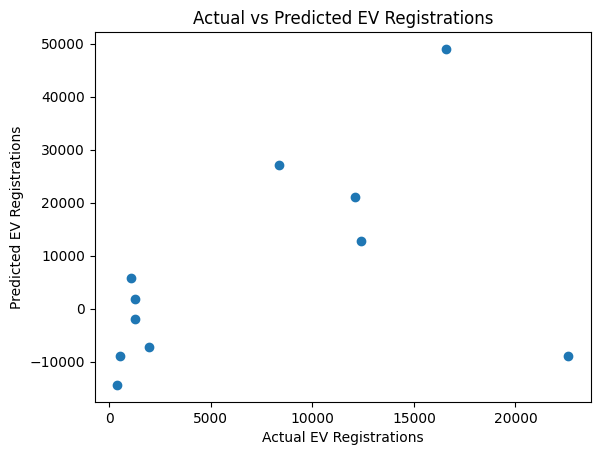

'The model was evaluated using Mean Absolute Error (MAE) and R² score to assess prediction accuracy'

In [122]:

plt.scatter(y_test, y_pred)
plt.xlabel("Actual EV Registrations")
plt.ylabel("Predicted EV Registrations")
plt.title("Actual vs Predicted EV Registrations")
plt.show()

"""The model was evaluated using Mean Absolute Error (MAE) and R² score to assess prediction accuracy"""

In [ ]:
"""The model demonstrates that EV registrations can be partially predicted using total vehicles and energy generation. 
However, the prediction accuracy is limited, indicating that additional factors such as policies, infrastructure, and 
incentives also influence EV adoption"""

In [ ]:
# 🚀 ✅ TASK 7.1: Impact of Policies-------------
"""The analysis of electric vehicle registrations and energy generation 
indicates that states with higher renewable energy production tend to exhibit
higher levels of EV adoption. This suggests that supportive policies,
infrastructure development, and investment in clean energy play a significant
role in promoting electric mobility.

- States with higher energy generation show better EV adoption.
- Regions with developed infrastructure tend to have more vehicle registrations.
- Policy-driven incentives likely contribute to increased EV usage.

In [ ]:
# 🚀 TASK 7.2: Effectiveness of Incentives
"""“Government incentives such as subsidies, tax benefits, and infrastructure
support appear to positively influence EV adoption. However, variations across
states indicate that policy implementation and accessibility play a crucial
role in determining effectiveness

- States with better infrastructure show higher EV penetration.
- Incentives alone are not sufficient without supporting energy systems.
- Long-term growth depends on sustainable energy availability."""

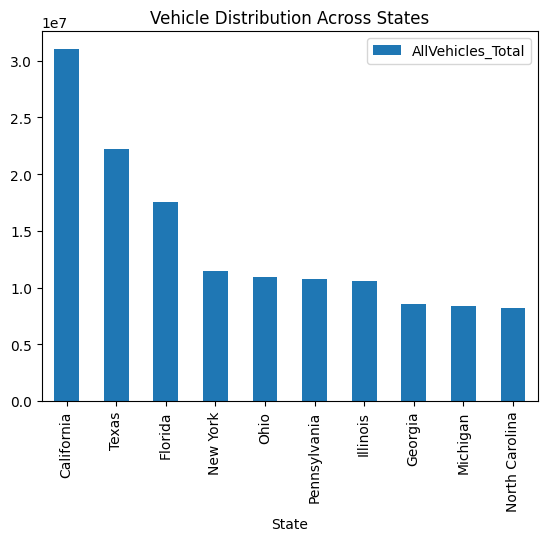

'Higher vehicle concentration in certain states suggests greater demand, \nwhich may influence policy focus and EV adoption strategies'

In [123]:
df_vehicle.sort_values(by='AllVehicles_Total', ascending=False).head(10).plot(
    x='State', y='AllVehicles_Total', kind='bar'
)
plt.title("Vehicle Distribution Across States")
plt.show()

"""Higher vehicle concentration in certain states suggests greater demand, 
which may influence policy focus and EV adoption strategies"""